# Multiscale Modeling of Biological Systems: Neuroscience - Assignment


## Setup

Follow instructions in `README.md` and import needed files


In [14]:
import rsatoolbox as rsa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.get_backend())

from core import SantoroDataset, MODEL_CLASSES, extract_activations

from torch.utils.data import DataLoader
from torch import Tensor


module://matplotlib_inline.backend_inline


## Part I


In [15]:
dataset = SantoroDataset()

categories = set(dataset.categories)

print(f"Unique Categories ({len(categories)}):", categories)
print("Models:", ", ".join(MODEL_CLASSES.keys()))

Unique Categories (73): {'accordion', 'water', 'toothbrush', 'bass', 'monkey', 'car', 'horn', 'bell', 'whistle', 'percussion', 'duck', 'insect', 'ensamble', 'river', 'wind', 'guitar', 'waves', 'man', 'dishes', 'drum', 'thunder', 'sawing', 'keys', 'flute', 'gun', 'chimes', 'bells', 'rain', 'bottle', 'waterfall', 'baby', 'glass', 'hammer', 'cat', 'horse', 'siren', 'wolf', 'zipper', 'wood', 'harmonica', 'motor', 'metal', 'woman', 'synthesizer', 'organ', 'sheep', 'chicken', 'hairdryer', 'door', 'trumpet', 'harp', 'cutting', 'dice', 'phone', 'bird', 'bagpipe', 'paper', 'toilet', 'clock', 'typewriter', 'piano', 'engine', 'ocean', 'goat', 'violin', 'clarinet', 'firework', 'brush', 'elastic', 'cow', 'pig', 'sitar', 'dog'}
Models: waveform, uninspired, inspired


### Brain responses data

- columns = features gathered from the STG.
- rows = each category (e.g. bird sound).


In [41]:
# Create rsatoolbox dataset:
def calculate_rdm(tensor: Tensor):
    rsa_data = rsa.data.Dataset(
        tensor.detach().cpu().reshape(tensor.shape[0], -1).numpy() 
    )

    return rsa.rdm.calc_rdm(rsa_data, method='correlation')


# Fix just in case it does not show up on its own
def show_rdm(rdm, **kwargs):
    fig, axes, handles = rsa.vis.show_rdm(rdm_stg, **kwargs)
    plt.show()

### 1. RDMs


#### a) STG brain data


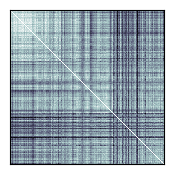

In [36]:
rdm_stg = calculate_rdm(dataset.brain_responses)

show_rdm(rdm_stg)

#### b) each layer of the three provided untrained models


In [ ]:
for model_name, ModelClass in MODEL_CLASSES.items():
    print(model_name)
    
    model = ModelClass(num_classes=50)

    loader = DataLoader(dataset, batch_size=16, shuffle=False)

    activations = extract_activations(loader, model)

    untrained_rdms = {}

    for layer_name, layer_act in activations.items():
        untrained_rdms[layer_name] = calculate_rdm(layer_act)

    layer_names = list(untrained_rdms)

    all_rdms = rsa.rdm.concat(
        *(untrained_rdms[name] for name in layer_names)
    )

    all_rdms.rdm_descriptors["layer"] = layer_names

    fig, axes, handles = rsa.vis.show_rdm(
        all_rdms,
        rdm_descriptor="layer",
        n_column=3,
        show_colorbar="figure",  # shared scale across panels
        figsize=(12, 8),
    )

    plt.show()

ValueError: too many values to unpack (expected 2)

#### c) each layer of the three provided trained models
